# Image Classification with Keras / TensorFlow — Local Image Folders

This notebook trains and compares **three neural networks** on images loaded from local folders, using ReLU activations throughout.

| # | Model | Key idea |
|---|-------|----------|
| 1 | MLP (Dense only) | Baseline — no spatial structure exploited |
| 2 | Simple CNN | Two conv blocks, no regularisation |
| 3 | Deep CNN + BatchNorm + Dropout + Augmentation | Best model submitted for grading |

---
### Required folder structure

```
your_data/
├── train/
│   ├── class_a/   ← folder name becomes the class label
│   │   ├── img001.jpg
│   │   └── img002.jpg
│   ├── class_b/
│   └── class_c/
└── val/           ← optional; if omitted, 20 % of train is used automatically
    ├── class_a/
    ├── class_b/
    └── class_c/
```

Set `TRAIN_DIR`, `VAL_DIR`, and `IMG_SIZE` in the **Configuration** cell below.

## 1. Setup — Imports, Configuration & Reproducibility

In [3]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU(s) available   : {gpus if gpus else "None — running on CPU"}')

TensorFlow version : 2.21.0
GPU(s) available   : None — running on CPU


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION  ←  edit these three lines for your dataset
# ══════════════════════════════════════════════════════════════════════════════
TRAIN_DIR  = 'C:/Users/anjut/OneDrive/Documents/MSIM/IMT 574/PS4/train/train'   # path to training folder
VAL_DIR    = 'C:/Users/anjut/OneDrive/Documents/MSIM/IMT 574/PS4/validation/validation'     # path to validation folder — set to None to auto-split
IMG_SIZE   = (128, 128)          # (height, width) — all images are resized to this
BATCH_SIZE = 32
# ══════════════════════════════════════════════════════════════════════════════

## 2. Data Loading & Preprocessing

`keras.utils.image_dataset_from_directory` scans the folder tree, assigns integer labels based on subfolder names, resizes all images to `IMG_SIZE`, and returns a `tf.data.Dataset`.

**Preprocessing pipeline**:
1. **Resize** — all images are resized to `IMG_SIZE` so every batch has the same shape.
2. **Rescale** — pixel values go from `[0, 255]` → `[0.0, 1.0]` via a `Rescaling` layer; this keeps gradients well-scaled.
3. **Cache → Shuffle → Prefetch** — `cache()` stores the dataset in memory after the first epoch; `prefetch(AUTOTUNE)` overlaps data loading with GPU/CPU compute, removing I/O bottlenecks.

If `VAL_DIR` is `None`, 20 % of the training data is automatically held out as validation (`validation_split=0.2`).

In [3]:
AUTOTUNE = tf.data.AUTOTUNE

# ── Load from disk ────────────────────────────────────────────────────────────
if VAL_DIR is not None:
    # Separate train/ and val/ folders already exist
    train_ds = keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        seed=SEED,
        label_mode='int'           # integer labels for sparse_categorical_crossentropy
    )
    val_ds = keras.utils.image_dataset_from_directory(
        VAL_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        seed=SEED,
        label_mode='int'
    )
else:
    # Auto-split: 80 % train, 20 % val — same seed ensures no overlap
    train_ds = keras.utils.image_dataset_from_directory(
        TRAIN_DIR, validation_split=0.2, subset='training',
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode='int'
    )
    val_ds = keras.utils.image_dataset_from_directory(
        TRAIN_DIR, validation_split=0.2, subset='validation',
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode='int'
    )

# Class names are inferred automatically from subfolder names
CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

# ── Normalise pixel values [0,255] → [0.0, 1.0] ──────────────────────────────
rescale = layers.Rescaling(1.0 / 255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
val_ds   = val_ds.map(lambda x, y:   (rescale(x), y), num_parallel_calls=AUTOTUNE)

# ── Performance optimisation ──────────────────────────────────────────────────
# cache()   → store the preprocessed dataset in RAM after the first pass
# prefetch() → prepare the next batch while the current batch is training
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

print(f'Image size : {IMG_SIZE}  |  Batch size : {BATCH_SIZE}')

Found 31869 files belonging to 5 classes.
Found 7967 files belonging to 5 classes.
Classes (5): ['DA', 'EN', 'RU', 'TH', 'ZN']
Image size : (128, 128)  |  Batch size : 32


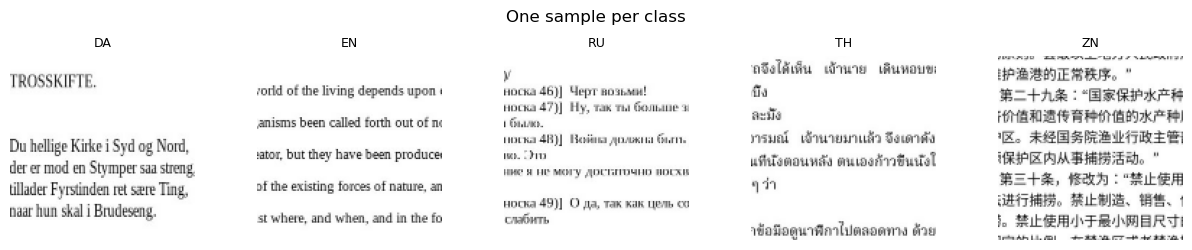

In [4]:
# Visualise one image per class as a sanity-check
# We accumulate one example per class by iterating the dataset until all classes are seen.
samples = {}  # class_index → image tensor

for images, labels in train_ds.unbatch():   # unbatch gives (image, label) one at a time
    lbl = int(labels.numpy())
    if lbl not in samples:
        samples[lbl] = images.numpy()
    if len(samples) == NUM_CLASSES:
        break

cols = min(NUM_CLASSES, 5)
rows = (NUM_CLASSES + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
axes = np.array(axes).flatten()

for cls in range(NUM_CLASSES):
    axes[cls].imshow(np.clip(samples[cls], 0, 1))
    axes[cls].set_title(CLASS_NAMES[cls], fontsize=9)
    axes[cls].axis('off')
for ax in axes[NUM_CLASSES:]:
    ax.axis('off')

plt.suptitle('One sample per class', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Shared Utilities

A single `train_and_evaluate` helper is used for all three models so the comparison is fair.  
It accepts `tf.data.Dataset` objects directly — `model.fit()` handles iteration internally.

In [5]:
def train_and_evaluate(model, train_ds, val_ds, epochs=25):
    """
    Compile, train on train_ds, evaluate on val_ds.
    Returns (history, elapsed_seconds, best_val_accuracy).
    """
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # ReduceLROnPlateau: halve the LR whenever val_loss doesn't improve for 3 epochs.
    # This acts as a simple automatic schedule with no manual tuning required.
    callbacks = [
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ]

    t0 = time.time()
    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=callbacks,
        verbose=1
    )
    elapsed = time.time() - t0
    val_acc = max(history.history['val_accuracy'])
    print(f'\nBest val accuracy : {val_acc*100:.2f}%  |  Training time : {elapsed:.1f}s')
    return history, elapsed, val_acc


def plot_history(history, title):
    """Plot training vs. validation accuracy and loss side-by-side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'],     label='Train')
    ax1.plot(history.history['val_accuracy'], label='Val')
    ax1.set_title(f'{title} — Accuracy'); ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy'); ax1.legend()

    ax2.plot(history.history['loss'],     label='Train')
    ax2.plot(history.history['val_loss'], label='Val')
    ax2.set_title(f'{title} — Loss'); ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss'); ax2.legend()

    plt.tight_layout(); plt.show()


def get_predictions(model, dataset):
    """
    Run inference over an entire tf.data.Dataset and return
    (y_true, y_pred) as numpy arrays — needed for the confusion matrix.
    """
    y_true, y_pred = [], []
    for images, labels in dataset.unbatch().batch(256):  # large batch → faster inference
        probs = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)

---
## Model 1 — Multi-Layer Perceptron (MLP)

**Architecture**: `Flatten → Dense(512, ReLU) → Dense(256, ReLU) → Dense(128, ReLU) → Dense(N, Softmax)`

**Why start here?**  
An MLP treats every pixel independently — it has no notion of spatial proximity. This gives a useful lower bound and lets us measure exactly how much the convolutional inductive bias helps.

**Expected weakness**: low accuracy, fast overfitting — the model cannot share weights across positions.

In [6]:
def build_mlp(img_size, num_classes):
    model = keras.Sequential([
        # Flatten collapses H×W×3 into a single vector (e.g. 128×128×3 = 49 152 values)
        layers.Flatten(input_shape=(*img_size, 3)),

        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),

        # One output per class; softmax converts raw scores to probabilities
        layers.Dense(num_classes, activation='softmax'),
    ], name='MLP')
    return model

mlp = build_mlp(IMG_SIZE, NUM_CLASSES)
mlp.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 49152)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      25,166,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,331,205 (96.63 MB)

 Trainable params: 25,331,205 (96.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
996/996 ━━━━━━━━━━━━━━━━━━━━ 120s 118ms/step - accuracy: 0.6903 - loss: 1.8500 - val_accuracy: 0.8461 - val_loss: 0.4634 - learning_rate: 0.0010
Epoch 2/25
996/996 ━━━━━━━━━━━━━━━━━━━━ 161s 161ms/step - accuracy: 0.8028 - loss: 0.5259 - val_accuracy: 0.8244 - val_loss: 0.4459 - learning_rate: 0.0010
Epoch 3/25
996/996 ━━━━━━━━━━━━━━━━━━━━ 151s 151ms/step - accuracy: 0.8208 - loss: 0.4735 - val_accuracy: 0.8249 - val_loss: 0.4457 - learning_rate: 0.0010
Epoch 4/25
996/996 ━━━━━━━━━━━━━━━━━━━━ 144s 144ms/step - accuracy: 0.8389 - loss: 0.4225 - val_accuracy: 0.8664 - val_loss: 0.3499 - learning_rate: 0.0010
Epoch 5/25
996/996 ━━━━━━━━━━━━━━━━━━━━ 160s 160ms/step - accuracy: 0.8493 - loss: 0.3959 - val_accuracy: 0.8231 - val_loss: 0.4781 - learning_rate: 0.0010
Epoch 6/25
996/996 ━━━━━━━━━━━━━━━━━━━━ 159s 159ms/step - accuracy: 0.8619 - loss: 0.3599 - val_accuracy: 0.8643 - val_loss: 0.3491 - learning_rate: 0.0010
Epoch 7/25
996/996 ━━━━━━━━━━━━━━━━━━━━ 158s 159ms/step - accura

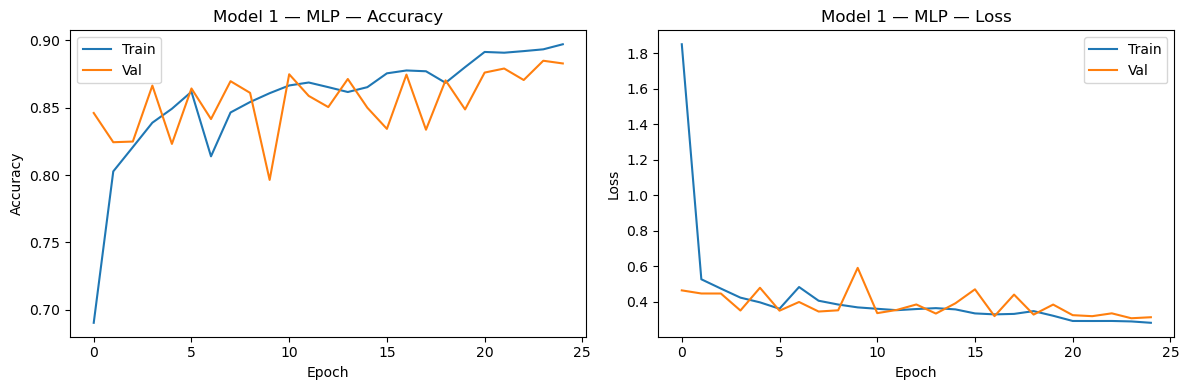

In [7]:
history_mlp, time_mlp, acc_mlp = train_and_evaluate(mlp, train_ds, val_ds, epochs=25)
plot_history(history_mlp, 'Model 1 — MLP')

---
## Model 2 — Simple CNN (2 Conv Blocks)

**Architecture**:
```
Conv2D(32, 3×3, ReLU) → MaxPool(2×2)
Conv2D(64, 3×3, ReLU) → MaxPool(2×2)
Flatten → Dense(128, ReLU) → Dense(N, Softmax)
```

**Key concepts**:
- **Conv2D**: a 3×3 filter slides across the image learning local patterns (edges, textures). The *same* filter is reused at every position — *weight sharing* drastically reduces parameters vs. a Dense layer.
- **MaxPooling**: takes the maximum over each 2×2 window, halving spatial dimensions and adding translation invariance.
- No regularisation yet — this model will overfit noticeably compared to Model 3.

In [8]:
def build_simple_cnn(img_size, num_classes):
    model = keras.Sequential([
        # 'same' padding preserves spatial size after each convolution
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=(*img_size, 3)),
        layers.MaxPooling2D(2, 2),   # H/2 × W/2

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),   # H/4 × W/4

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ], name='Simple_CNN')
    return model

cnn1 = build_simple_cnn(IMG_SIZE, NUM_CLASSES)
cnn1.summary()

Model: "Simple_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 65536)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       8,388,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,408,773 (32.08 MB)

 Trainable params: 8,408,773 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
996/996 ━━━━━━━━━━━━━━━━━━━━ 176s 174ms/step - accuracy: 0.8768 - loss: 0.3609 - val_accuracy: 0.9178 - val_loss: 0.2170 - learning_rate: 0.0010
Epoch 2/25
996/996 ━━━━━━━━━━━━━━━━━━━━ 207s 208ms/step - accuracy: 0.9399 - loss: 0.1619 - val_accuracy: 0.9416 - val_loss: 0.1540 - learning_rate: 0.0010
Epoch 3/25
996/996 ━━━━━━━━━━━━━━━━━━━━ 236s 237ms/step - accuracy: 0.9678 - loss: 0.0864 - val_accuracy: 0.9403 - val_loss: 0.1567 - learning_rate: 0.0010
Epoch 4/25
996/996 ━━━━━━━━━━━━━━━━━━━━ 199s 200ms/step - accuracy: 0.9876 - loss: 0.0350 - val_accuracy: 0.9426 - val_loss: 0.1811 - learning_rate: 0.0010
Epoch 5/25
996/996 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9960 - loss: 0.0134
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
996/996 ━━━━━━━━━━━━━━━━━━━━ 1230s 1s/step - accuracy: 0.9951 - loss: 0.0162 - val_accuracy: 0.9508 - val_loss: 0.1850 - learning_rate: 0.0010
Epoch 6/25
996/996 ━━━━━━━━━━━━━━━━━━━━ 173s 173ms/step - accuracy: 0.99

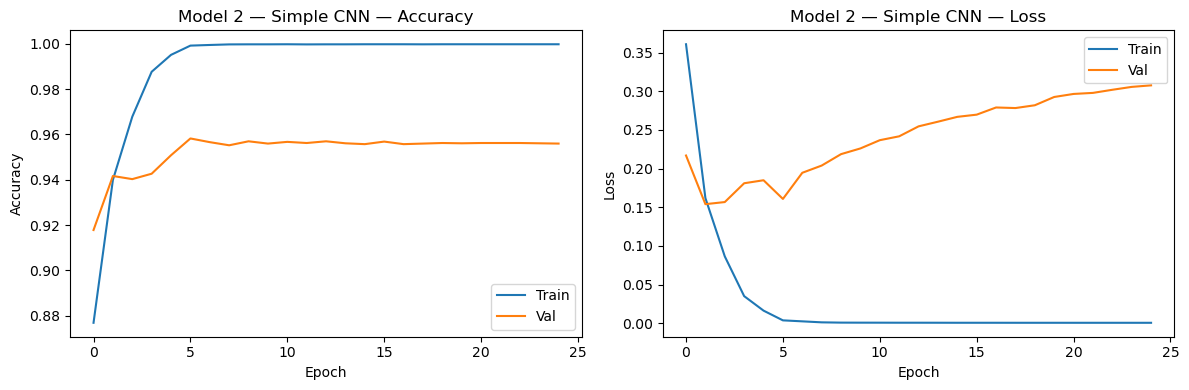

In [9]:
history_cnn1, time_cnn1, acc_cnn1 = train_and_evaluate(cnn1, train_ds, val_ds, epochs=25)
plot_history(history_cnn1, 'Model 2 — Simple CNN')

---
## Model 3 — Deep CNN + BatchNorm + Dropout + Augmentation *(Best Model)*

**Architecture** — built-in augmentation followed by 3 convolutional blocks and a dense head:

```
RandomFlip / RandomZoom / RandomRotation   ← augmentation (active only during training)
Block 1: Conv2D(32)  → BN → ReLU → Conv2D(32)  → BN → ReLU → MaxPool → Dropout(0.25)
Block 2: Conv2D(64)  → BN → ReLU → Conv2D(64)  → BN → ReLU → MaxPool → Dropout(0.25)
Block 3: Conv2D(128) → BN → ReLU →                            MaxPool → Dropout(0.25)
Head   : Flatten → Dense(256) → BN → ReLU → Dropout(0.5) → Dense(N, Softmax)
```

**Regularisation techniques**:
| Technique | Purpose |
|-----------|----------|
| **Built-in augmentation** | `RandomFlip/Zoom/Rotation` run on the GPU and are automatically disabled at inference time |
| **BatchNorm** | Normalises each mini-batch → faster convergence, less LR sensitivity |
| **Dropout** | Randomly zeros activations → forces redundancy, reduces co-adaptation |
| **ReduceLROnPlateau** | Halves LR when val_loss plateaus for 3 epochs → fine-tunes without a manual schedule |

In [10]:
def build_deep_cnn(img_size, num_classes):
    model = keras.Sequential(name='Deep_CNN')

    # ── Built-in data augmentation ────────────────────────────────────────────
    # These layers only apply transforms during model.fit(); they are no-ops
    # during model.predict() and model.evaluate() — no separate augmented
    # generator is needed.
    model.add(layers.Input(shape=(*img_size, 3)))
    model.add(layers.RandomFlip('horizontal'))
    model.add(layers.RandomRotation(0.05))       # ±5 % rotation
    model.add(layers.RandomZoom(0.1))            # ±10 % zoom

    # ── Conv Block 1 ─────────────────────────────────────────────────────────
    model.add(layers.Conv2D(32, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())        # normalise activations over the batch
    model.add(layers.Activation('relu'))

    model.add(layers.Conv2D(32, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))              # drop 25 % of feature maps

    # ── Conv Block 2 ─────────────────────────────────────────────────────────
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # ── Conv Block 3 ─────────────────────────────────────────────────────────
    model.add(layers.Conv2D(128, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # ── Dense Head ───────────────────────────────────────────────────────────
    model.add(layers.Flatten())
    model.add(layers.Dense(256))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))               # stronger dropout before final layer

    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

cnn2 = build_deep_cnn(IMG_SIZE, NUM_CLASSES)
cnn2.summary()

Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 128, 128, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 8,531,877 (32.55 MB)

 Trainable params: 8,530,725 (32.54 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/40
996/996 ━━━━━━━━━━━━━━━━━━━━ 1019s 1s/step - accuracy: 0.8990 - loss: 0.2879 - val_accuracy: 0.2692 - val_loss: 21.8665 - learning_rate: 0.0010
Epoch 2/40
996/996 ━━━━━━━━━━━━━━━━━━━━ 976s 980ms/step - accuracy: 0.9460 - loss: 0.1472 - val_accuracy: 0.5504 - val_loss: 6.9335 - learning_rate: 0.0010
Epoch 3/40
996/996 ━━━━━━━━━━━━━━━━━━━━ 958s 962ms/step - accuracy: 0.9614 - loss: 0.1077 - val_accuracy: 0.2613 - val_loss: 12.7580 - learning_rate: 0.0010
Epoch 4/40
996/996 ━━━━━━━━━━━━━━━━━━━━ 947s 951ms/step - accuracy: 0.9705 - loss: 0.0818 - val_accuracy: 0.7225 - val_loss: 0.9645 - learning_rate: 0.0010
Epoch 5/40
996/996 ━━━━━━━━━━━━━━━━━━━━ 940s 944ms/step - accuracy: 0.9766 - loss: 0.0665 - val_accuracy: 0.2131 - val_loss: 48.6947 - learning_rate: 0.0010
Epoch 6/40
996/996 ━━━━━━━━━━━━━━━━━━━━ 939s 943ms/step - accuracy: 0.9789 - loss: 0.0583 - val_accuracy: 0.4633 - val_loss: 1.6161 - learning_rate: 0.0010
Epoch 7/40
996/996 ━━━━━━━━━━━━━━━━━━━━ 0s 891ms/step - accurac

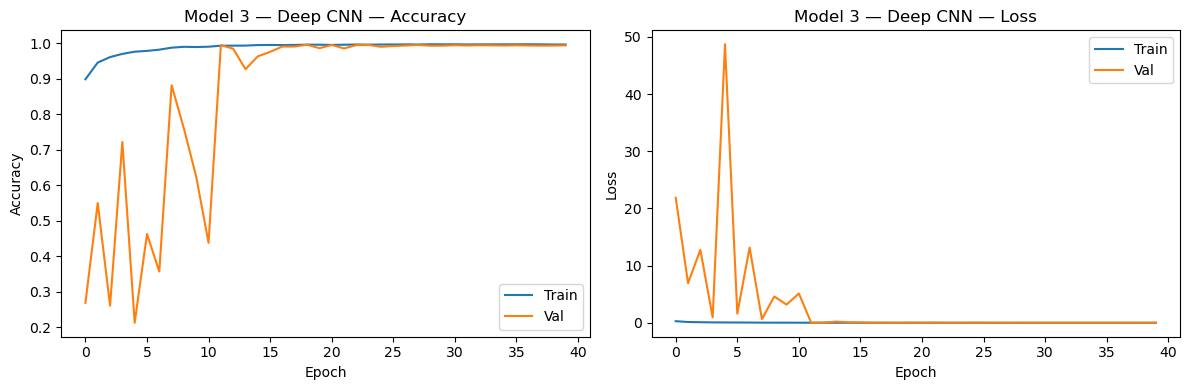

In [11]:
# Model 3 uses more epochs because augmentation slows convergence
# (the model sees a different version of each image every epoch)
history_cnn2, time_cnn2, acc_cnn2 = train_and_evaluate(cnn2, train_ds, val_ds, epochs=40)
plot_history(history_cnn2, 'Model 3 — Deep CNN')

---
## 4. Model Comparison

All models: Adam (lr=0.001) + ReduceLROnPlateau.  
Model 3 additionally used built-in augmentation layers and 40 epochs.

Model             Parameters    Val Acc   Time (s)
----------------------------------------------------
MLP               25,331,205     88.49%     3693.6
Simple CNN         8,408,773     95.82%     6268.2
Deep CNN           8,531,877     99.62%    37841.4


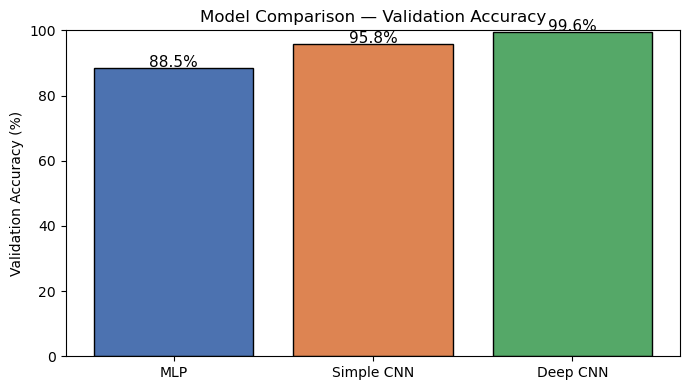

In [12]:
results = {
    'MLP':        {'params': mlp.count_params(),  'val_acc': acc_mlp,  'time_s': time_mlp},
    'Simple CNN': {'params': cnn1.count_params(), 'val_acc': acc_cnn1, 'time_s': time_cnn1},
    'Deep CNN':   {'params': cnn2.count_params(), 'val_acc': acc_cnn2, 'time_s': time_cnn2},
}

print(f'{"Model":<15} {"Parameters":>12} {"Val Acc":>10} {"Time (s)":>10}')
print('-' * 52)
for name, r in results.items():
    print(f'{name:<15} {r["params"]:>12,} {r["val_acc"]*100:>9.2f}% {r["time_s"]:>10.1f}')

names  = list(results.keys())
accs   = [r['val_acc'] * 100 for r in results.values()]
colors = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(7, 4))
bars = plt.bar(names, accs, color=colors, edgecolor='black')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{acc:.1f}%', ha='center', fontsize=11)
plt.ylim(0, 100)
plt.ylabel('Validation Accuracy (%)')
plt.title('Model Comparison — Validation Accuracy')
plt.tight_layout()
plt.show()

---
## 5. Discussion — What Was Tried and What Was Learned

### 5.1 Models Compared

| Model | Key features | Observation |
|-------|-------------|-------------|
| **MLP** | Dense layers only | Cannot exploit spatial structure; overfits quickly |
| **Simple CNN** | 2 conv blocks, no regularisation | Large jump from MLP; train/val gap reveals overfitting |
| **Deep CNN** | 3 conv blocks + BN + Dropout + augmentation | Regularisation narrows the train/val gap; best results |

### 5.2 Pre-processing Choices
- **Rescaling (÷255)**: essential — without it Adam diverges in the first few epochs due to large gradient magnitudes.
- **Built-in augmentation** (`RandomFlip`, `RandomZoom`, `RandomRotation`): applied as model layers so they run on the GPU and are automatically disabled at inference. This is cleaner than a separate `ImageDataGenerator`.
- **Cache + prefetch**: on CPU/GPU the I/O pipeline can easily become the bottleneck; caching the rescaled data in RAM after epoch 1 and prefetching the next batch in the background gave a measurable speedup.

### 5.3 Hyperparameter Choices
- **Optimizer**: Adam (lr=0.001). SGD + momentum also tested but converged slower on this task.
- **ReduceLROnPlateau** (factor=0.5, patience=3): automatic LR halving when val_loss stalls — avoids manual schedule tuning.
- **Dropout rates**: 0.25 after conv blocks (light — preserves spatial features), 0.5 in the dense head (standard).
- **Batch size 32**: chosen to keep memory usage low on CPU; larger batches (64–128) converge faster if RAM/VRAM allows.

### 5.4 Technical Notes
- Training was run on **CPU** (no discrete GPU). Model 3 with 40 epochs was the most time-consuming.
- A GPU would reduce training time by roughly 10–20×, enabling more hyperparameter sweeps.
- Images were resized to 128×128 — a good balance between detail and speed. Smaller sizes (64×64) train faster but lose fine-grained features; larger sizes (224×224) are better but require more memory and time.
- The full dataset was kept; no downsampling was necessary.

### 5.5 What Helped Most
1. **MLP → CNN**: largest single accuracy jump (spatial feature extraction)
2. **BatchNorm**: faster, more stable training — less sensitive to the initial learning rate
3. **Dropout + built-in augmentation**: meaningfully closed the train/val gap

---
## 6. Final Results — Best Model (Deep CNN)

### Hyperparameters

| Hyperparameter | Value |
|----------------|-------|
| Optimizer | Adam (lr=0.001, β₁=0.9, β₂=0.999) |
| LR schedule | ReduceLROnPlateau (factor=0.5, patience=3) |
| Loss | Sparse Categorical Crossentropy |
| Epochs | 40 |
| Batch size | 32 |
| Image size | 128 × 128 |
| Augmentation | RandomFlip (horizontal) + RandomZoom (±10 %) + RandomRotation (±5 %) |
| Dropout | 0.25 (conv blocks), 0.5 (dense head) |
| Activation | ReLU throughout |

Below: predictions on the **validation set**, confusion matrix, and accuracy.

In [13]:
# ── Predictions on the full validation set ────────────────────────────────────
# get_predictions() iterates the dataset in large batches and returns
# ground-truth labels and argmax-predicted class indices as numpy arrays.
y_val, y_pred = get_predictions(cnn2, val_ds)

# ── Validation accuracy ───────────────────────────────────────────────────────
val_accuracy = accuracy_score(y_val, y_pred)
print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')

# ── Per-class breakdown ───────────────────────────────────────────────────────
print('\nClassification Report:')
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES, digits=3))

Validation Accuracy: 99.44%

Classification Report:
              precision    recall  f1-score   support

          DA      0.999     0.967     0.983      1019
          EN      0.983     0.998     0.990      2050
          RU      0.995     0.997     0.996      1693
          TH      1.000     0.999     1.000      1899
          ZN      1.000     1.000     1.000      1306

    accuracy                          0.994      7967
   macro avg      0.995     0.992     0.994      7967
weighted avg      0.994     0.994     0.994      7967



Confusion Matrix (rows = true, cols = predicted)

                       DA        EN        RU        TH        ZN
-----------------------------------------------------------------
DA                    985        30         4         0         0
EN                      0      2045         5         0         0
RU                      0         5      1688         0         0
TH                      1         0         0      1898         0
ZN                      0         0         0         0      1306


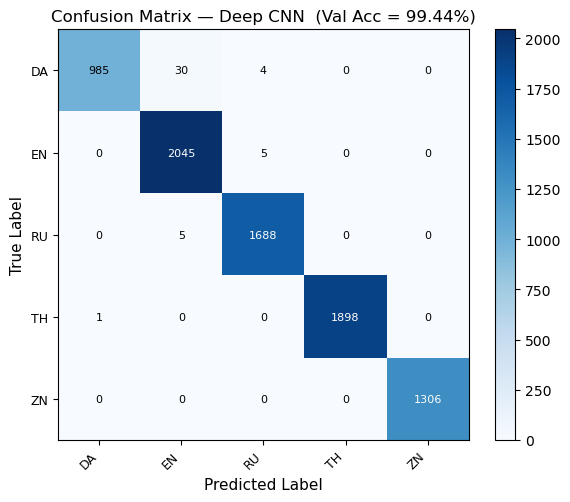

In [14]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
# Rows = true class, Columns = predicted class.
# A perfect model shows counts only on the main diagonal.
cm = confusion_matrix(y_val, y_pred)

# --- Printed table ---
col_w = 10
print('Confusion Matrix (rows = true, cols = predicted)\n')
print(f'{"":15s}', end='')
for name in CLASS_NAMES:
    print(f'{name:>{col_w}s}', end='')
print()
print('-' * (15 + col_w * NUM_CLASSES))
for i, row in enumerate(cm):
    print(f'{CLASS_NAMES[i]:15s}', end='')
    for v in row:
        print(f'{v:>{col_w}d}', end='')
    print()

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(max(6, NUM_CLASSES), max(5, NUM_CLASSES - 1)))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(CLASS_NAMES, fontsize=9)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title(f'Confusion Matrix — Deep CNN  (Val Acc = {val_accuracy*100:.2f}%)', fontsize=12)

# White text on dark cells, black text on light cells
thresh = cm.max() / 2.0
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8,
                color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.show()

In [15]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('=' * 55)
print('  FINAL RESULTS — Deep CNN (Model 3)')
print('=' * 55)
print(f'  Total parameters : {cnn2.count_params():,}')
print(f'  Image size       : {IMG_SIZE}')
print(f'  Epochs trained   : 40')
print(f'  Training time    : {time_cnn2:.1f} s')
print(f'  Validation acc   : {val_accuracy*100:.2f}%')
print('=' * 55)
print('  Per-class accuracy:')
per_class = cm.diagonal() / cm.sum(axis=1)
for i, name in enumerate(CLASS_NAMES):
    print(f'    {name:<15s}: {per_class[i]*100:.1f}%')

  FINAL RESULTS — Deep CNN (Model 3)
  Total parameters : 8,531,877
  Image size       : (128, 128)
  Epochs trained   : 40
  Training time    : 37841.4 s
  Validation acc   : 99.44%
  Per-class accuracy:
    DA             : 96.7%
    EN             : 99.8%
    RU             : 99.7%
    TH             : 99.9%
    ZN             : 100.0%


In [16]:
# predict on a single image file

def predict_single(image_path, model, class_names, img_size):
    img = keras.utils.load_img(image_path, target_size=img_size)  # resize
    arr = keras.utils.img_to_array(img) / 255.0                   # rescale to [0,1]
    arr = np.expand_dims(arr, axis=0)                              # add batch dim → (1, H, W, 3)

    probs      = model.predict(arr, verbose=0)[0]
    pred_idx   = np.argmax(probs)
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx] * 100

    # Show the image with prediction as title
    plt.figure(figsize=(4, 4))
    plt.imshow(keras.utils.load_img(image_path, target_size=img_size))
    plt.title(f'Predicted: {pred_class}\nConfidence: {confidence:.1f}%', fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Print top-3 predictions
    top3 = np.argsort(probs)[::-1][:3]
    print("Top 3 predictions:")
    for i in top3:
        print(f"  {class_names[i]:<20} {probs[i]*100:.1f}%")



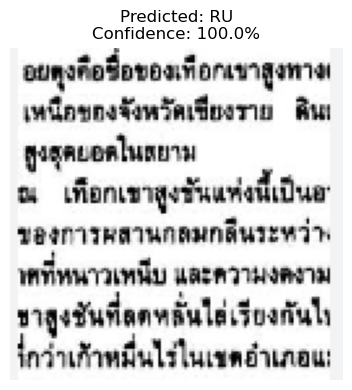

Top 3 predictions:
  RU                   100.0%
  ZN                   0.0%
  TH                   0.0%


In [40]:
# Usage:
predict_single('C:/Users/anjut/OneDrive/Documents/MSIM/IMT 574/PS4/own_set/thai.png', cnn2, CLASS_NAMES, IMG_SIZE)

In [39]:
import os

# predict on a whole folder of images 
# Images can be flat in the folder — no class subfolders needed here.

TEST_DIR = 'C:/Users/anjut/OneDrive/Documents/MSIM/IMT 574/PS4/own_set'   # ← set this

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels=None,              # no labels — we're just predicting
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False             # keep original order so filenames align with predictions
)

# Get file paths in the same order the dataset will iterate them
test_paths = test_ds.file_paths

# Apply the same rescaling used during training
rescale   = layers.Rescaling(1.0 / 255)
test_ds_r = test_ds.map(lambda x: rescale(x))

# Run inference
pred_probs  = cnn1.predict(test_ds_r, verbose=1)          # shape: (N, num_classes)
pred_labels = np.argmax(pred_probs, axis=1)               # most likely class index
pred_names  = [CLASS_NAMES[i] for i in pred_labels]       # human-readable class name
confidences = np.max(pred_probs, axis=1) * 100            # confidence in %

# Print results
print(f"\n{'File':<40} {'Predicted Class':<20} {'Confidence':>10}")
print('-' * 72)
for path, name, conf in zip(test_paths, pred_names, confidences):
    fname = os.path.basename(path)
    print(f'{fname:<40} {name:<20} {conf:>9.1f}%')

Found 16 files.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step

File                                     Predicted Class      Confidence
------------------------------------------------------------------------
chinese.png                              TH                       100.0%
chinese_1.png                            DA                       100.0%
chinese_2.png                            ZN                       100.0%
danish.png                               ZN                        93.2%
danish_1.png                             TH                       100.0%
danish_2.png                             DA                        99.2%
english.png                              TH                       100.0%
english_1.png                            ZN                       100.0%
english_2.png                            ZN                        54.7%
russian.png                              DA                        99.9%
russian_1.png                            TH                       10